# Project 1: Image registration

**Contents:** <br>

- [Goal](#goal)<br>
- [Deliverables](#deliverables)<br>
- [Assessment](#assessment)<br>

- [Preliminary guided project work](#guided_work)<br>

    A. [Getting started](#getting_started)<br>
    - [Dataset](#dataset)<br>
    - [Selecting corresponding point pairs](#selecting_point_pairs)<br>
        
  B. [Point-based registration](#point-based_reg)<br>
    - [Point-based affine image registration](#affine)<br>
    - [Evaluation of point-based affine image registration](#evaluation)<br>
        
  C. [Intensity-based registration](#intensity-based_reg)<br>
    - [Comparing the results of different registration methods](#comparison)<br>

- [Open-ended project work](#open-end)

# NOTE FOR THE TEACHING ASSISTANT:

This notebook contains all image registration done for project 1. Most of the functions needed to run these cells are stored in the accompanying Python file titled `registration_project.py`. Also, please make sure to change any variables named `data_path` to match the path to the MR images on your local machine. Thank you.

<div id="goal"></div>

<div style="float:right;margin:-5px 5px"><img src="assets/read_ico.png" width="42" height="42"></div> 


## Goal
Develop Python code for point-based and intensity-based (medical) image registration. Propose and investigate a suitable research question of your choice. Use the developed code to perform image registration and evaluate and analyze the results.

The dataset you will be using in the first project originates from the [MRBrainS medical image analysis challenge](http://mrbrains13.isi.uu.nl/). It consists of 18 traverse slices of MR brain scans with two different sequences: T1-weighted and T2-FLAIR (3 patients $\times$ 3 slices per patient $\times$ 2 modalities). Please see the [Getting started](#getting_started) assignment below for more details on the dataset.

The assignment consists of two parts, as a first step there is preliminary guided project work, and as a second step you must investigate a suitable research question based on the methods you have developed. A research question based on the preliminary guided project work below, completing the programming tasks and answering the theory questions, is the minimal solution to this project. If this is done well and accompanied by a suitable report, this will be graded with a ‘sufficient’ grade. To achieve higher grades, you need to go beyond the minimal solution. You should use what you have implemented and the available data to come up with and answer a suitable research question. Write about this in your report.

<div id="deliverables"></div>

## Deliverables
A completed version of this notebook, the documented python code that you developed, and a report describing your research question, results and analysis. The report is expected in a short, concise format. It focusses on your specific research questions, results and discussion. The lecturers already know the background, the data and the general methodology. Your report therefore does not need to include an introduction on the clinical problem nor explanations of the background of image registration. You do have to include your design choices and motivation thereof.

Aim to present your most important findings in the main body of the report and (if needed) any additional information in an appendix. The following report structure is suggested for the main body of the report:

1. Introduce research question and hypothesis with its motivation (0.5 page)
2. Study design: which data did you use, what are the requirements of your method,
why did you make certain choices. Be as complete as possible w.r.t. the components
of a study design. (0.5 page)
3. Method, experiments and results (2 pages)
4. Discussion section with analysis of the results. (1 page)
5. Contributions: a brief description by each group member of their activities in the project which can be used to to adjust individual grades to reflect a student’s (lack of) contribution to the group
6. If you use large language models (such as ChatGPT) in your course work, you are required to declare how and for what they were used and to include a reflection on the use of such tools.

The page lengths above are indications. You are free to adapt them, with the constraint of a maximum length of five pages for the first four items listed.

The report must be submitted as a single PDF file. The documented code must be submitted as a single archive file (e.g. zip or 7z) that is self-contained and can be used to reproduce the results in the report. 

Note that there is no single correct solution for the project. You have to demonstrate to the reader that you understand the methods that you have studied and can critically analyze the results of applying the methods. Below, you can find a set of assignments (guided project work) that will help you get started with the project work and, when correctly completed, will present you with a **minimal solution**. Solutions which go beyond these assignments are of course encouraged. Additionally, include the solutions to the preliminary guided project work within this notebook in the archive file. 
<div id="assessment"></div>

## Assessment
The rubric that will be used for assessment of the project work is given in [this table](https://github.com/tueimage/8BE030-MIA/blob/master/rubric.md). Please check this carefully!

In [ ]:
%load_ext autoreload
%autoreload 2

<div id='guided_work'></div>

## Preliminary guided project work

<div id="getting_started"></div>
<div style="float:right;margin:-5px 5px"><img src="assets/read_ico.png" width="42" height="42"></div> 

### A. Getting started
As an introduction, you will get familiar with the dataset that will be used in the first project and the control point selection tool that can be used to annotate corresponding points in pairs of related images. The annotated points can later be used to perform point-based registration and evaluation of the registration error.

In [2]:
import sys
sys.path.append("../code")
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from registration_project import *

<div id="dataset"></div>

### Dataset

The image dataset is located in the [image_data](https://github.com/tueimage/8BE030-MIA/tree/master/data/image_data) subfolder of the code for the registration exercises and project. The image filenames have the following format: `{Patient ID}_{Slice ID}_{Sequence}.tif`. For example, the filename `3_2_t1.tif` is the second slice from a T1-weighted scan of the third patient. Every T1 slice comes in two versions: original and transformed with some random transformation that can be identified with the `_d` suffix in the filename. This simulates a registration problem where you have to register two image acquisitions of the same patient (note however that some of the transformations that were used to simulate the second set of images are not realistic for brain imaging, e.g. brain scans typically do not encounter shearing between consecutive acquisitions).

<div style="float:right;margin:-5px 5px"><img src="assets/question_ico.png" width="42" height="42"></div> 

### *Question 1*:

With this dataset we can define two image registration problems: T1 to T1 registration (e.g. register `3_2_t1_d.tif` to `3_2_t1.tif`) and T2 to T1 registration (e.g. register `3_2_t2.tif` to `3_2_t1.tif`). Which one of these can be considered inter-modal image registration and which one intra-modal image registration?

_Answer: T1 to T1 registration is intra-modal image registration, while T2 to T1 registration is inter-modal image registration. Intra-modal registration involves aligning images that are acquired using the same imaging modality (in this case, both images are T1-weighted), while inter-modal registration involves aligning images that are acquired using different imaging modalities (in this case one is T2 and the other is T1-weighted)._

<div id="selecting_point_pairs"></div>

### Selecting corresponding point pairs

A function called `cpselect` is provided to select control points in two different images. This function provides two numpy np.arrays of cartesian coordinates, one array for each image, of points selected in the two images. The coordinate format is a numpy array with the X and Y on row 0 and 1 respectively, and each column being a point.

Calling the function will cause a new interactive window to pop up, where you will see your two images and some instructions.
For convenience, the instructions can also be found below:

* First select a point in Image 1 and then its corresponding point in Image 2. This pattern should be repeated for as many control points as you need. If you do not follow this pattern, the output arrays will be incorrect.
* Left Mouse Button to create a point. 
* Right Mouse Button/Delete/Backspace to remove the newest point. 
* Middle Mouse Button/Enter to finish placing points. 

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 

### *Task 1*:

Test the functionality of `cpselect` by running the following code example:

In [ ]:
I_path = '../data/image_data/1_1_t1.tif'
Im_path = '../data/image_data/1_1_t1_d.tif'

subprocess.check_call([sys.executable, "-m", "pip", "install", "PyQt5"])

X, Xm = cpselect(I_path, Im_path)

print('X:\n{}'.format(X))
print('Xm:\n{}'.format(Xm))

<div id="point-based_reg"></div>

## B. Point-based registration

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 

<div id="affine"></div>

### Point-based affine image registration

From the provided dataset for this project, select one pair of T1 image slices (e.g. `3_2_t1.tif` and `3_2_t1_d.tif`) and use `my_cpselect` to select a set of corresponding points. Then, compute the affine transformation between the pair of images with `ls_affine` and apply it to the moving image using `image_transform`. If you want to use a set of default manually selected control points, you can uncomment the code in the cell below and use those values instead of running `cpselect`.

Repeat the same for a pair of corresponding T1 and T2 slices (e.g. `3_2_t1.tif` and `3_2_t2.tif`).

In [ ]:
data_path = '../data/image_data/'
# Select first pair of T1-weighted images
Im1_path = data_path + '1_1_t1.tif'
Im2_path = data_path + '1_1_t1_d.tif'

Points_Im1, Points_Im2 = cpselect(Im1_path, Im2_path)

print('Points_Im1:\n{}'.format(Points_Im1))
print('Points_Im2:\n{}'.format(Points_Im2))

In [ ]:
# THE SELECTED POINTS:
# Points_Im1 = np.array([[125.96451613, 144.7, 219.21612903,  92.32580645, 112.33870968,
#   162.58387097, 149.38387097,  81.25483871,  74.01612903],
#  [105.92045161, 134.87529032, 135.30109677, 224.72045161, 240.90109677,
#   105.92045161,  48.8623871,  136.15270968, 150.63012903]])
# Points_Im2 = np.array([[125.69354839, 144.85483871, 218.51935484,  93.33225806, 112.91935484,
#   162.31290323, 149.96451613,  81.40967742,  75.02258065],
#  [108.04948387, 135.30109677, 135.72690323, 226.42367742, 242.17851613,
#   106.34625806,  49.714      , 135.30109677, 148.07529032]])

X = Points_Im2
Xm = Points_Im1
T = ls_affine(X, Xm)
print('T:\n{}'.format(T))

<div id="evaluation"></div>

### Evaluation of point-based affine image registration

<div style="float:right;margin:-5px 5px"><img src="assets/question_ico.png" width="42" height="42"></div> 

### *Question 2*:
Describe how you would estimate the registration error. (Hint: Should you use the same points that you used for computing the affine transformation to also compute the registration error?) How does the number of corresponding point pairs affect the registration error? Motivate all your answers.

_Answer: To estimate the registration error, we can compute the affine transformation with only a partial set of our control points. We then use our computed affine transformation to transform the control points in the fixed image. We then compute the difference between the estimated transformed control point and the initially set-aside control points. This gives us a measure of how well our acquired transformation estimates the true image registration._

<div id="intensity-based_reg"></div>

## C. Intensity-based registration

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 

<div id="comparison"></div>

### Comparing the results of different registration methods

The following Python script (provided as `intensity_based_registration_demo()`) performs rigid intensity-based registration of two images using the normalized-cross correlation as a similarity metric:

In [ ]:
%matplotlib inline

intensity_based_registration_demo(
    I_path='../data/image_data/1_1_t1.tif',
    Im_path='../data/image_data/1_1_t1_d.tif',
    similarity_func=rigid_corr,
    mu=0.001,
    num_iter=200,
    init_val=np.array([0., 0., 0.]))

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 

### *Task 2*:

By changing the similarity function and the initial parameter vector, you can also use this script to perform affine registration and use mutual information as a similarity measure. Do not forget to also change the transformation for the visualization of the results.

Using the provided dataset and the functions that you have implemented in the exercises, perform the following series of experiments:

1. Rigid intensity-based registration of two T1 slices (e.g. `1_1_t1.tif` and `1_1_t1_d.tif`) using normalized cross-correlation as a similarity measure.
2. Affine intensity-based registration of two T1 slices (e.g. `1_1_t1.tif` and `1_1_t1_d.tif`) using normalized cross-correlation as a similarity measure.
3. Affine intensity-based registration of a T1 and a T2 slice (e.g. `1_1_t1.tif` and `1_1_t2.tif`) using normalized cross-correlation as a similarity measure.
4. Affine intensity-based registration of two T1 slices (e.g. `1_1_t1.tif` and `1_1_t1_d.tif`) using mutual information as a similarity measure.
5. Affine intensity-based registration of a T1 slice and a T2 slice (e.g. `1_1_t1.tif` and `1_1_t2.tif`) using mutual information as a similarity measure.

Compare the results from each experiment. If a method fails, describe why you think it fails. Note that you will most likely have to try different values for the learning rate in each experiment in order to find the one that works best. 

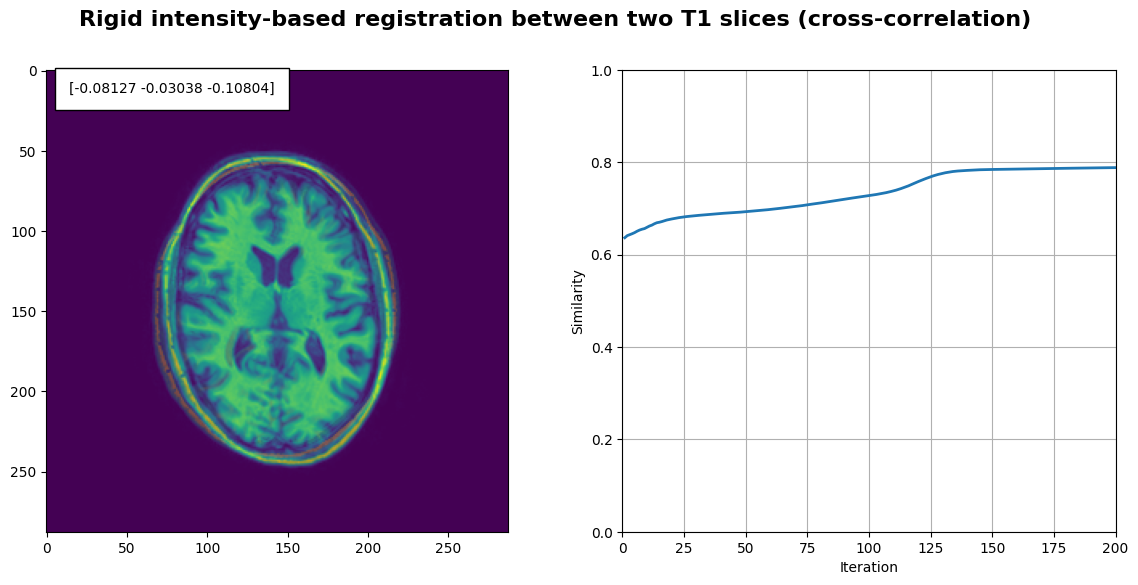

In [84]:
# 1. Rigid intensity-based registration between two T1 slices (cross-correlation)
S1, Im_t1, Th1 = intensity_based_registration_demo(
    I_path='../data/image_data/2_2_t1.tif',
    Im_path='../data/image_data/2_2_t1_d.tif',
    similarity_func=rigid_corr,
    mu=0.001,
    num_iter=200,
    init_val=np.array([0., 0., 0.]),
    title="Rigid intensity-based registration between two T1 slices (cross-correlation)")

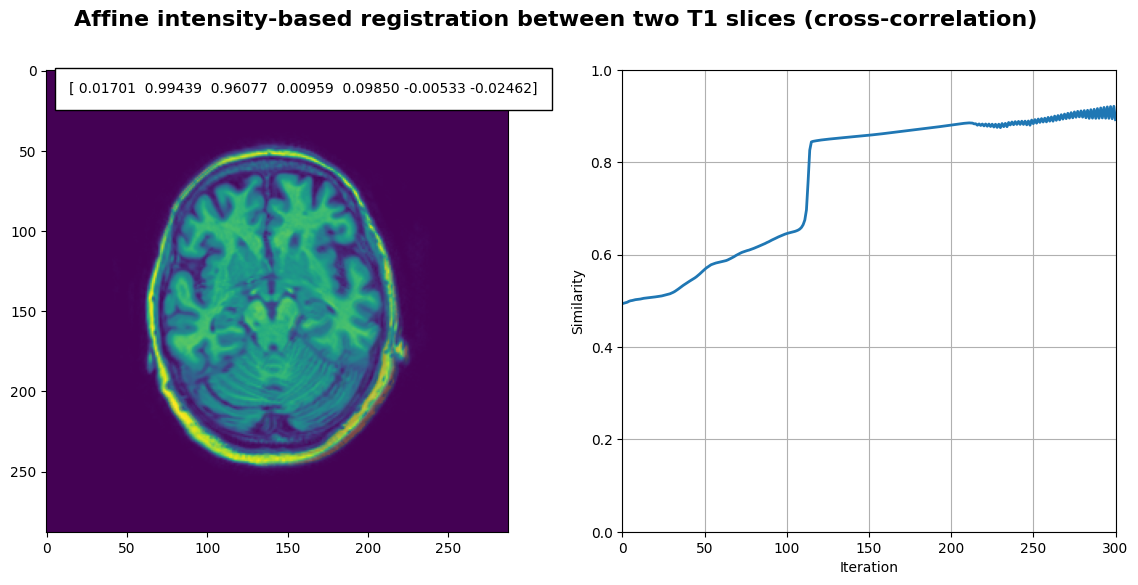

In [85]:
# 2. Affine intensity-based registration between two T1 slices (cross-correlation)
# x = [rot angle, scale x, scale y, shear x, shear y, trans x, trans y]
S2, Im_t2, Th2 = intensity_based_registration_demo(
    I_path='../data/image_data/3_1_t1.tif',
    Im_path='../data/image_data/3_1_t1_d.tif',
    similarity_func=affine_corr,
    mu=0.001,
    num_iter=300,
    init_val=np.array([0.1, 1, 1, 0.1, 0.1, 0.1, 0.1]),
    title="Affine intensity-based registration between two T1 slices (cross-correlation)")

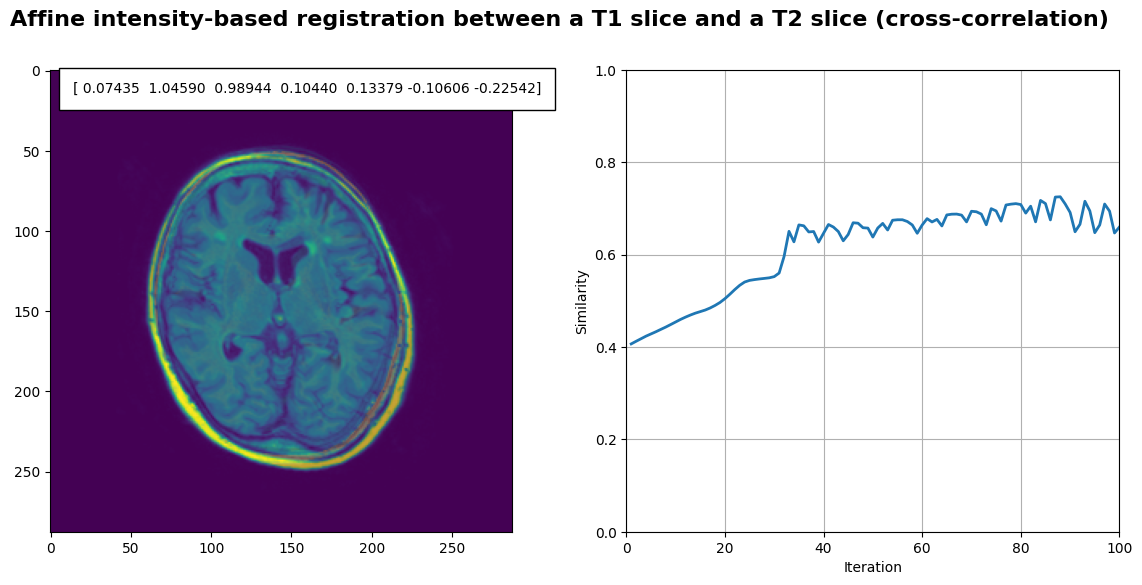

In [22]:
# 3. Affine intensity-based registration between a T1 slice and a T2 slice (cross-correlation)
# x = [rot angle, scale x, scale y, shear x, shear y, trans x, trans y]
S3, Im_t3, Th3 = intensity_based_registration_demo(
    I_path='../data/image_data/3_2_t1.tif',
    Im_path='../data/image_data/3_2_t2.tif',
    similarity_func=affine_corr,
    mu=0.002,
    num_iter=100,
    init_val=np.array([0.1, 1, 1, 0.2, 0.2, -0.2, -0.2]),
    title="Affine intensity-based registration between a T1 slice and a T2 slice (cross-correlation)")

In [ ]:
# 4. Affine intensity-based registration between two T1 slices (mutual information)
# x = [rot angle, scale x, scale y, shear x, shear y, trans x, trans y]
S4, Im_t4, Th4 = intensity_based_registration_demo(
    I_path='../data/image_data/1_1_t1.tif',
    Im_path='../data/image_data/1_1_t1_d.tif',
    similarity_func=affine_mi,
    mu=0.001,
    num_iter=100,
    init_val=np.array([0.1, 1., 1., 0., 0., 0.1, -0.15]),
    title="Affine intensity-based registration between two T1 slices (mutual information)")

In [ ]:
# 5. Affine intensity-based registration between a T1 slice and a T2 slice (mutual information)
# x = [rot angle, scale x, scale y, shear x, shear y, trans x, trans y]
S5, Im_t5, Th5 = intensity_based_registration_demo(
    I_path='../data/image_data/1_1_t1.tif',
    Im_path='../data/image_data/1_1_t2.tif',
    similarity_func=affine_mi,
    mu=0.001,
    num_iter=100,
    init_val=np.array([-0.1, 1., 1., 0., 0., -0.2, -0.03]),
    title="Affine intensity-based registration between a T1 slice and a T2 slice (mutual information)")

<div id="open-end"></div>

<div style="float:right;margin:-5px 5px"><img src="assets/todo_ico.png" width="42" height="42"></div> 


## Open-ended project work

Define and motivate one research question that you will investigate. This can be a question relating to a method (e.g. what is the impact of X on a particular method) or relating to the problem (e.g. does a specific method fail in specific cases). 
It is recommended to get feedback on your research question from the teaching assistants.

## Research question:
*_How do point-based, raw intensity-based, preprocessed intensity-based, and edge-based registration methods compare in the affine registration of T1-weighted and T2-FLAIR MR brain images?_*

In this project, we will perform image registration on data from MRI images taken from the brain. There are 3 subjects, and for each subject 3 slices are made per imaging modality. These modalities are T1-weighted and T2-FLAIR-weighted MRI. We will perform affine registration using different methods:

1. point-based registration using manually selected control points;
2. raw intensity-based registration; 
3. preprocessed intensity-based registration;
4. edge-based intensity-based registration.

For each method we will register the T2-FLAIR image (moving image) onto the T1-weighted image (fixed image). This yields nine total registrations per method, which we shall compare using various evaluation metrics (TBD, stuff like Dice, Jaccard, MI, etc.).

### 1. Point-based registration using manually selected control points
In this section we will perform point-based registration using manually selected control points. We will use the `cpselect` function to select corresponding points in pairs of related images, and then compute the affine transformation between the pair of images with `ls_affine` and apply it to the moving image using `image_transform`. We will also evaluate the registration error.

We will select a total of 20 control points per image pair, and use those points to compute the affine transformation. We will repeat this process for all 9 pairs of T1 and T2 images.

In [1]:
# LOADING ALL T1 AND T2 SLICES
data_path = '../data/image_data/'
image_pairs = [(data_path + '1_1_t1.tif', data_path + '1_1_t2.tif'),
               (data_path + '1_2_t1.tif', data_path + '1_2_t2.tif'),
               (data_path + '1_3_t1.tif', data_path + '1_3_t2.tif'),
               (data_path + '2_1_t1.tif', data_path + '2_1_t2.tif'),
               (data_path + '2_2_t1.tif', data_path + '2_2_t2.tif'),
               (data_path + '2_3_t1.tif', data_path + '2_3_t2.tif'),
               (data_path + '3_1_t1.tif', data_path + '3_1_t2.tif'),
               (data_path + '3_2_t1.tif', data_path + '3_2_t2.tif'),
               (data_path + '3_3_t1.tif', data_path + '3_3_t2.tif')]

In [ ]:
# SELECTING CONTROL POINTS AND PERFORMING POINT-BASED REGISTRATION FOR ALL 9 PAIRS OF T1 AND T2 IMAGES
# NOTE: If you want to verify our acquired results, then uncomment the bottom line (and comment out the other
#       lines). You will then load our list of 20 manually-selected control points for each of the nine image
#       pairs.

control_points = []
for i, (Im1_path, Im2_path) in enumerate(image_pairs):
    X, Xm = cpselect(Im1_path, Im2_path)
    control_points.append((X, Xm))

# control_points = load_manually_selected_control_points()

In [16]:
# PERFORMING POINT-BASED REGISTRATION FOR ALL 9 PAIRS OF T1 AND T2 IMAGES
# AND REPORTING THE REGISTRATION SIMILARITIES

point_based_registration_CC = []
point_based_registration_MI = []
point_based_registration_Dice = []
point_based_registration_Jaccard = []

for i, (Im1_path, Im2_path) in enumerate(image_pairs):
    Im1 = plt.imread(Im1_path)
    Im2 = plt.imread(Im2_path)

    # Compute the affine transformation
    X, Xm = control_points[i]
    T = ls_affine(X, Xm)
    Im_t, _ = image_transform(Im2, T)
    # Computing the registration errors
    CC = correlation(Im1, Im_t)
    MI = mutual_information(joint_histogram(Im1, Im_t))
    Dice = dice_score(Im1 > 0, Im_t > 0)
    Jaccard = jaccard_index(Im1 > 0, Im_t > 0)
    point_based_registration_CC.append(CC)
    point_based_registration_MI.append(MI)
    point_based_registration_Dice.append(Dice)
    point_based_registration_Jaccard.append(Jaccard)
    print(f"Subject {Im1_path[-10]} slice pair {Im1_path[-8]}: ")
    print(f"       CC: {CC:.4f}")
    print(f"       MI: {MI:.4f}")
    print(f"     Dice: {Dice:.4f}")
    print(f"  Jaccard: {Jaccard:.4f}")    

Subject 1 slice pair 1: 
       CC: 0.8643
       MI: 0.7072
     Dice: 0.8976
  Jaccard: 0.8142
Subject 1 slice pair 2: 
       CC: 0.8695
       MI: 0.7064
     Dice: 0.9013
  Jaccard: 0.8204
Subject 1 slice pair 3: 
       CC: 0.8770
       MI: 0.6848
     Dice: 0.8771
  Jaccard: 0.7811
Subject 2 slice pair 1: 
       CC: 0.8783
       MI: 0.6778
     Dice: 0.8744
  Jaccard: 0.7768
Subject 2 slice pair 2: 
       CC: 0.8999
       MI: 0.6814
     Dice: 0.8861
  Jaccard: 0.7954
Subject 2 slice pair 3: 
       CC: 0.8759
       MI: 0.6417
     Dice: 0.8677
  Jaccard: 0.7662
Subject 3 slice pair 1: 
       CC: 0.8930
       MI: 0.7313
     Dice: 0.8991
  Jaccard: 0.8167
Subject 3 slice pair 2: 
       CC: 0.8757
       MI: 0.7224
     Dice: 0.8870
  Jaccard: 0.7970
Subject 3 slice pair 3: 
       CC: 0.8851
       MI: 0.6803
     Dice: 0.8758
  Jaccard: 0.7790


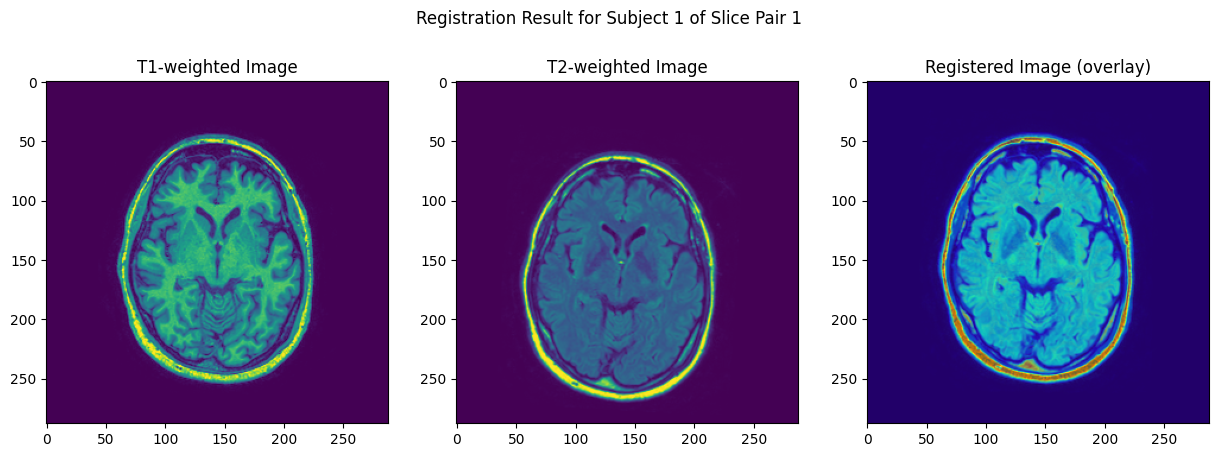

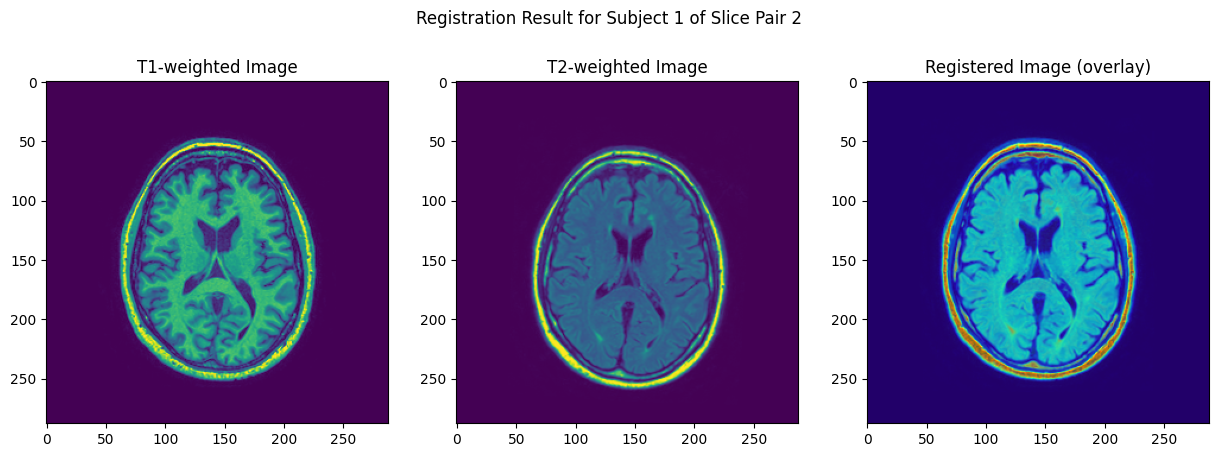

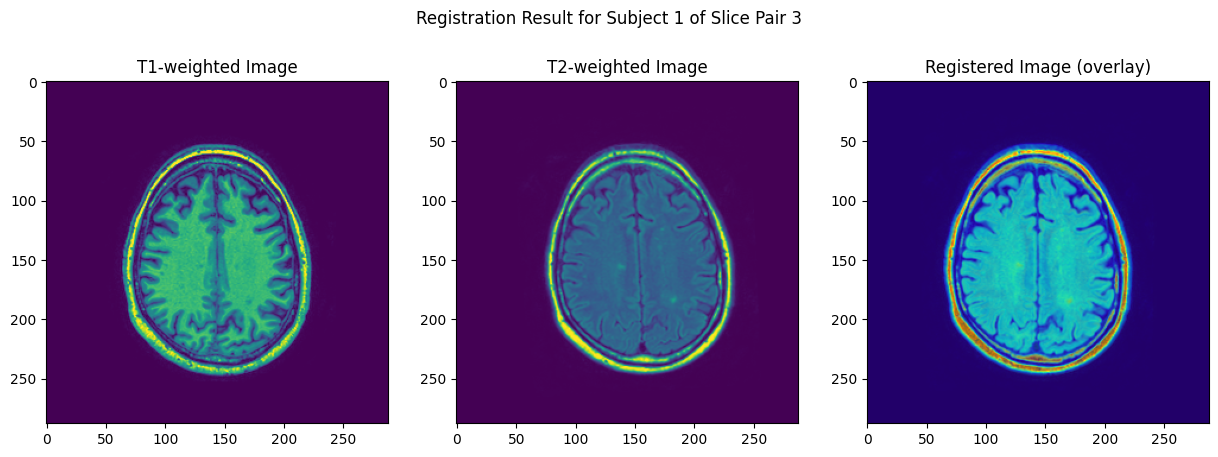

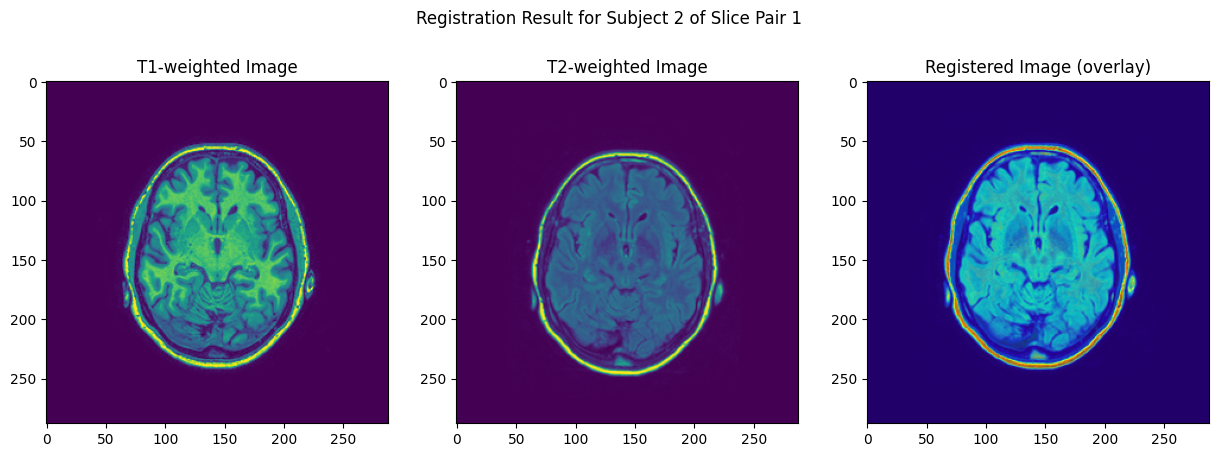

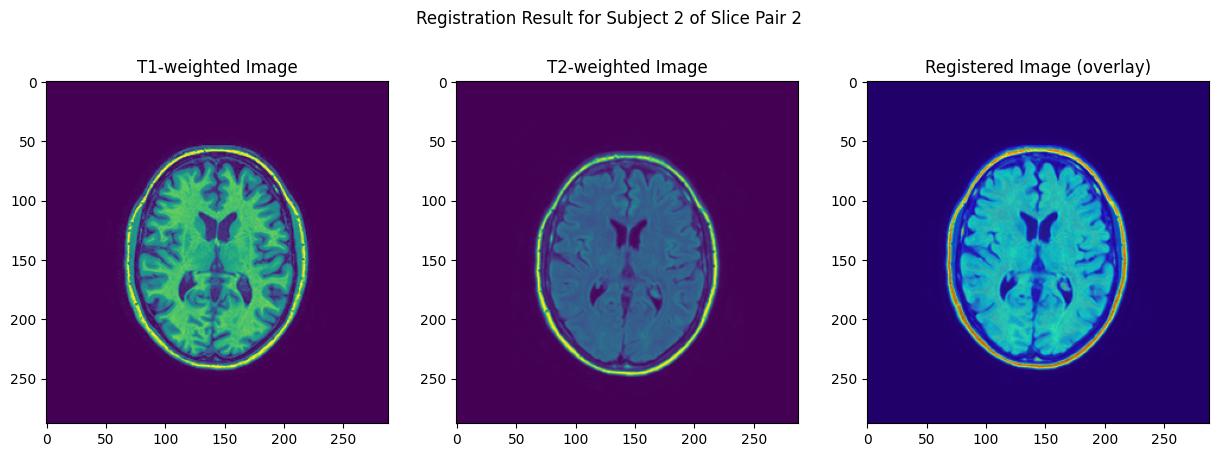

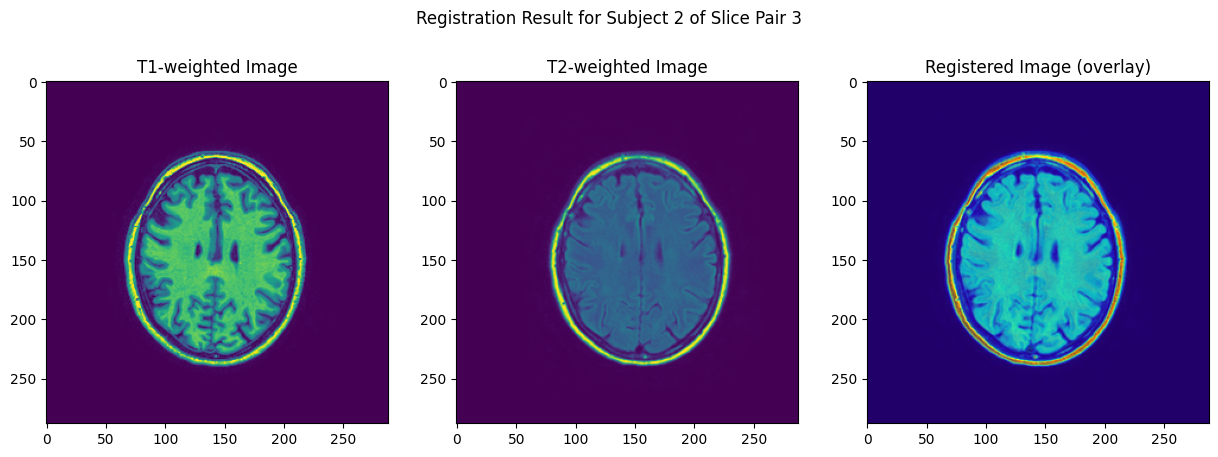

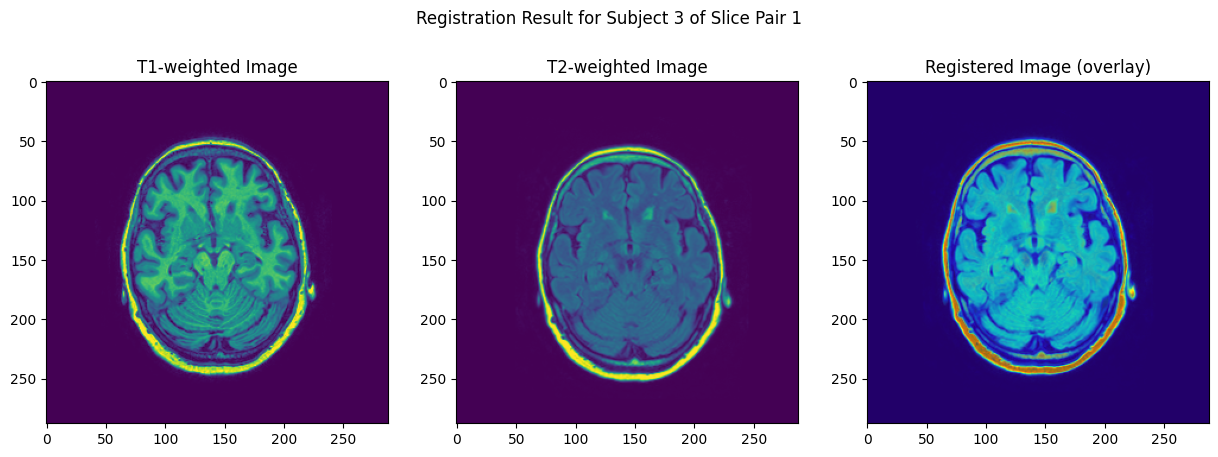

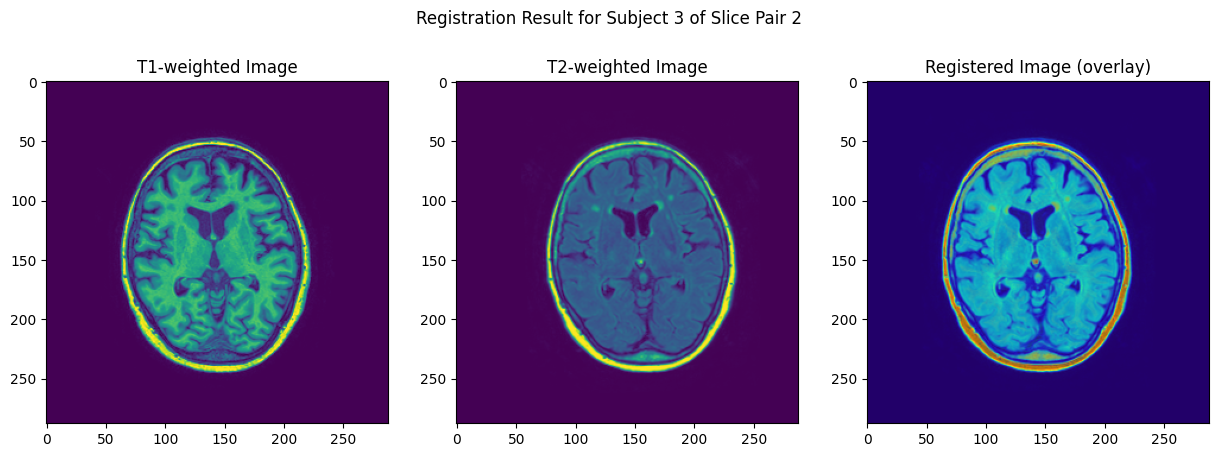

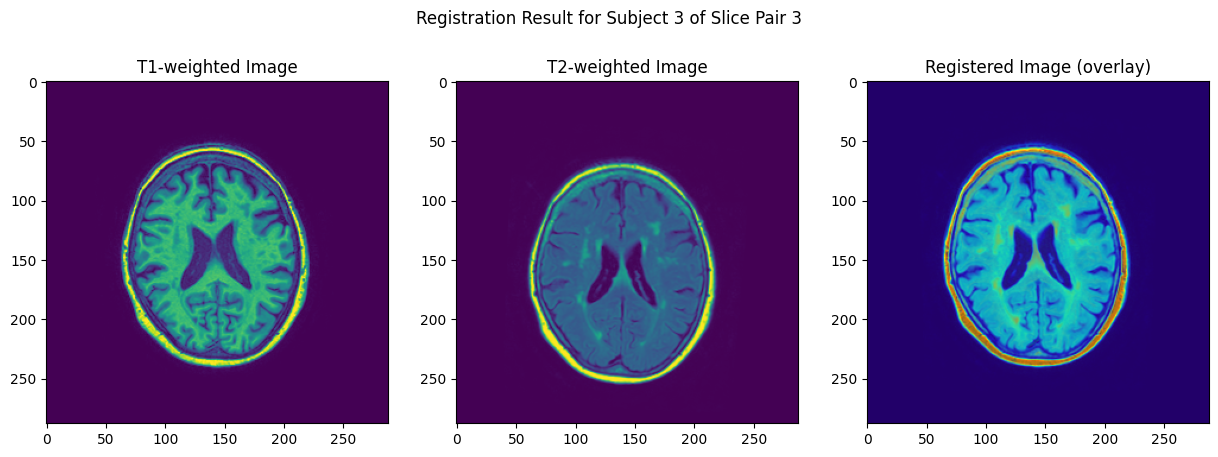

In [18]:
# VISUALIZING THE IMAGE REGISTRATION RESULTS FOR ALL 9 PAIRS OF T1 AND T2 IMAGES
for i, (Im1_path, Im2_path) in enumerate(image_pairs):
    Im1 = plt.imread(Im1_path)
    Im2 = plt.imread(Im2_path)
    X, Xm = control_points[i]
    T = ls_affine(X, Xm)
    Im_t, _ = image_transform(Im2, T)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(Im1)#, cmap='gray')
    axes[0].set_title("T1-weighted Image")
    axes[1].imshow(Im2)#, cmap='gray')
    axes[1].set_title("T2-weighted Image")
    axes[2].imshow(Im1)#, cmap='gray')
    axes[2].set_title("Registered Image (overlay)")
    axes[2].imshow(Im_t, cmap='jet', alpha=0.5)  # transparency
    plt.suptitle(f"Registration Result for Subject {Im1_path[-10]} of Slice Pair {Im1_path[-8]}")
    f": "
    plt.show()

### 2. Raw intensity-based registration

Now we will focus on intensity-based registration methods, starting with unprocessed, raw images. To this end, we can simply rely on the already implemented `intensity_based_registration_demo` function from before. 

#### 2.1 Performing image registration for each image pair

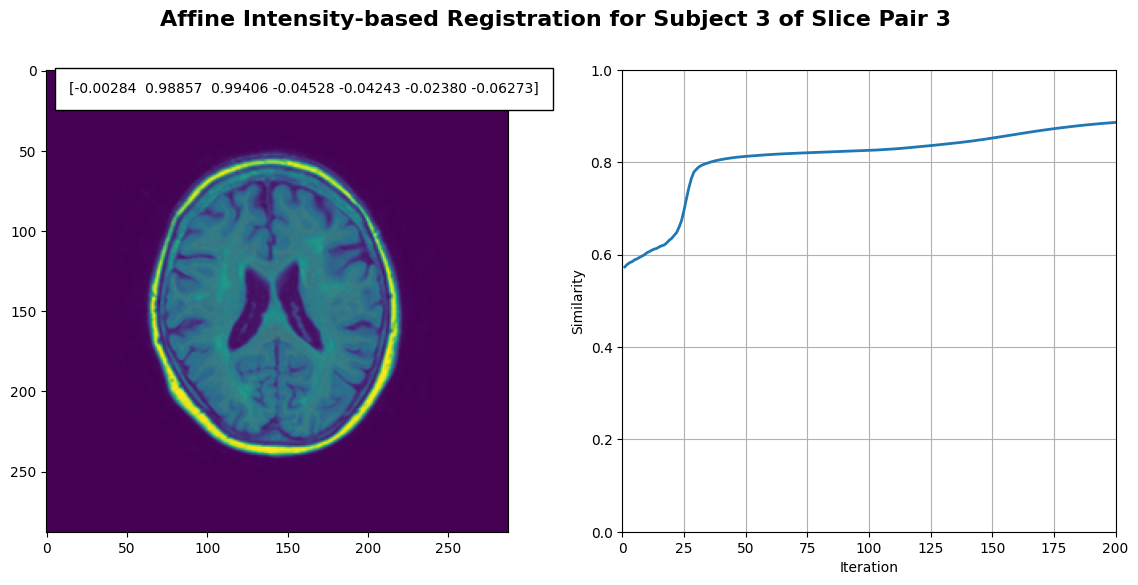

In [3]:
# PERFORMING AFFINE INTENSITY-BASED IMAGE REGISTRATION:
# - for each pair of (T1,T2)-weighted images perform registration;
# - store the final similarity metric, transformed image, and transformation in lists;
# - we use gradient descent with cross-correlation and central finite differences,
#   for a total of 200 epochs with learning rate 0.0005.

raw_S = []
raw_Im_t = []
raw_th = []
for i, (Im1_path, Im2_path) in enumerate(image_pairs):
    S, Im_t, Th = intensity_based_registration_demo(
        I_path = Im1_path,   # path to fixed image -> the T1-weighted image
        Im_path = Im2_path,  # path to moving image -> the T2-weighted image
        similarity_func = affine_corr,
        mu = 0.0005,
        num_iter = 200,
        init_val = np.array([0., 1., 1., 0., 0., 0., 0.]),  #[rot, scale x, scale y, shear x, shear y, trans x, trans y]
        title = f"Affine Intensity-based Registration for Subject {int(np.floor((i%9)/3+1))} of Slice Pair {i%3+1}")
    raw_S.append(S)
    raw_Im_t.append(Im_t)
    raw_th.append(Th)

#### 2.3 Evaluating the results of raw intensity-based registration 

In [10]:
raw_registration_CC = []
raw_registration_MI = []
raw_registration_Dice = []
raw_registration_Jaccard = []

for i, (Im1_path, Im2_path) in enumerate(image_pairs):
    Im1 = plt.imread(Im1_path)
    Im_t = raw_Im_t[i]
    
    # Computing the similarity scores
    CC = correlation(Im1, Im_t)
    MI = mutual_information(joint_histogram(Im1, Im_t))
    Dice = dice_score(Im1 > 0, Im_t > 0)
    Jaccard = jaccard_index(Im1 > 0, Im_t > 0)
    raw_registration_CC.append(CC)
    raw_registration_MI.append(MI)
    raw_registration_CC.append(Dice)
    raw_registration_MI.append(Jaccard)
    print(f"Subject {Im1_path[-10]} slice pair {Im1_path[-8]}: ")
    print(f"       CC: {CC:.4f}")
    print(f"       MI: {MI:.4f}")
    print(f"     Dice: {Dice:.4f}")
    print(f"  Jaccard: {Jaccard:.4f}")

Subject 1 slice pair 1: 
       CC: 0.5573
       MI: 0.4540
     Dice: 0.8634
  Jaccard: 0.7596
Subject 1 slice pair 2: 
       CC: 0.8783
       MI: 0.7076
     Dice: 0.9014
  Jaccard: 0.8205
Subject 1 slice pair 3: 
       CC: 0.8700
       MI: 0.6653
     Dice: 0.8756
  Jaccard: 0.7788
Subject 2 slice pair 1: 
       CC: 0.8674
       MI: 0.6556
     Dice: 0.8751
  Jaccard: 0.7779
Subject 2 slice pair 2: 
       CC: 0.8755
       MI: 0.6460
     Dice: 0.8836
  Jaccard: 0.7915
Subject 2 slice pair 3: 
       CC: 0.6095
       MI: 0.4041
     Dice: 0.8420
  Jaccard: 0.7271
Subject 3 slice pair 1: 
       CC: 0.8606
       MI: 0.6818
     Dice: 0.8967
  Jaccard: 0.8127
Subject 3 slice pair 2: 
       CC: 0.5528
       MI: 0.4213
     Dice: 0.8552
  Jaccard: 0.7471
Subject 3 slice pair 3: 
       CC: 0.8860
       MI: 0.6729
     Dice: 0.8738
  Jaccard: 0.7759


#### 2.4 Repeating image registration with different hyperparameters

Since the results for subject 1 pair 1, subject 2 pair 3, and subject 3 pair 2 are rather low, we will investigate how to improve these registrations. The visualizations show that the registration process seems to get stuck due to the low step size. Let us boost the convergence speed by setting the learning rate equal to 0.001 for the first 50 epochs, and return it to 0.0005 for the remaining ones.

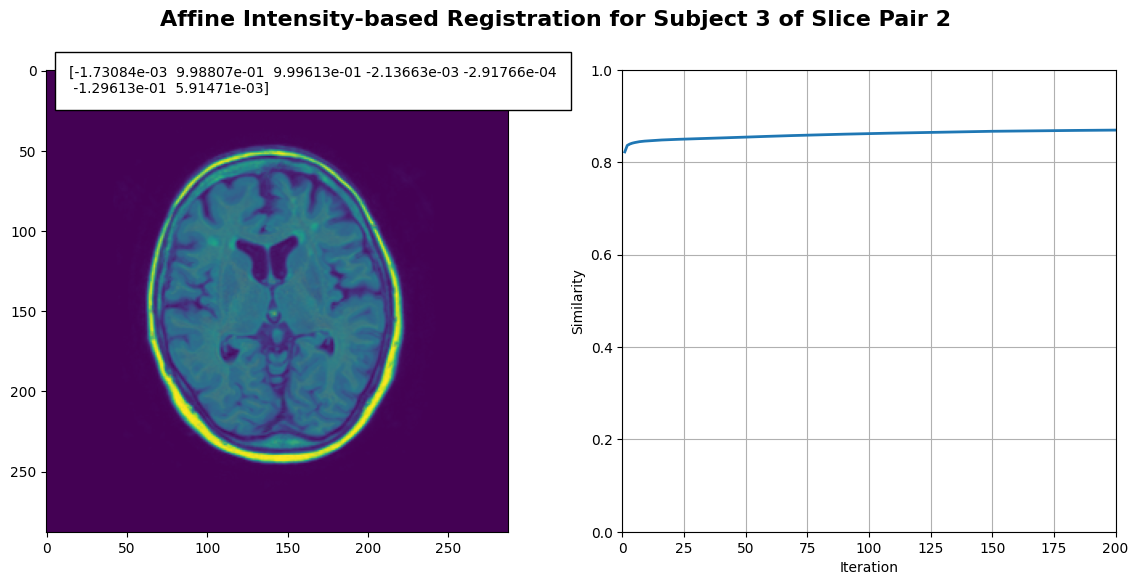

Subject 3 slice pair 2: 
       CC: 0.8693
       MI: 0.7043
     Dice: 0.8825
  Jaccard: 0.7898


In [4]:
import sys
sys.path.append("../code")
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from registration_project import *

data_path = '../data/image_data/'
image_pairs_to_improve = [
                            # (data_path + '1_1_t1.tif', data_path + '1_1_t2.tif')]
                        #   (data_path + '2_3_t1.tif', data_path + '2_3_t2.tif')]
                          (data_path + '3_2_t1.tif', data_path + '3_2_t2.tif')]


for i, (Im1_path, Im2_path) in enumerate(image_pairs_to_improve):
    S, Im_t, Th = intensity_based_registration_demo(
        I_path = Im1_path,   # path to fixed image -> the T1-weighted image
        Im_path = Im2_path,  # path to moving image -> the T2-weighted image
        similarity_func = affine_corr,
        mu = 0.0001,
        num_iter = 200,
        init_val = np.array([0., 1., 1., 0., 0., -0.15, 0.]),  #[rot, scale x, scale y, shear x, shear y, trans x, trans y]
        title = f"Affine Intensity-based Registration for Subject {Im1_path[-10]} of Slice Pair {Im1_path[-8]}")
Im1 = plt.imread(Im1_path)
CC = correlation(Im1, Im_t)
MI = mutual_information(joint_histogram(Im1, Im_t))
Dice = dice_score(Im1 > 0, Im_t > 0)
Jaccard = jaccard_index(Im1 > 0, Im_t > 0)
print(f"Subject {Im1_path[-10]} slice pair {Im1_path[-8]}: ")
print(f"       CC: {CC:.4f}")
print(f"       MI: {MI:.4f}")
print(f"     Dice: {Dice:.4f}")
print(f"  Jaccard: {Jaccard:.4f}")

### 3. Preprocessed intensity-based registration

A common technique to improve the performance of intensity-based registration is to preprocess the images before performing registration. In this section we will investigate whether this can also help in our case. We will apply a Gaussian filter to the images, a Contrast Limited Adaptive Histogram Equalization filter which enhances local contrasts in the image, and finally normalize the images. We do this for both fixed and moving image before performing registration.

#### 3.1 Showcasing the preprocessing effects

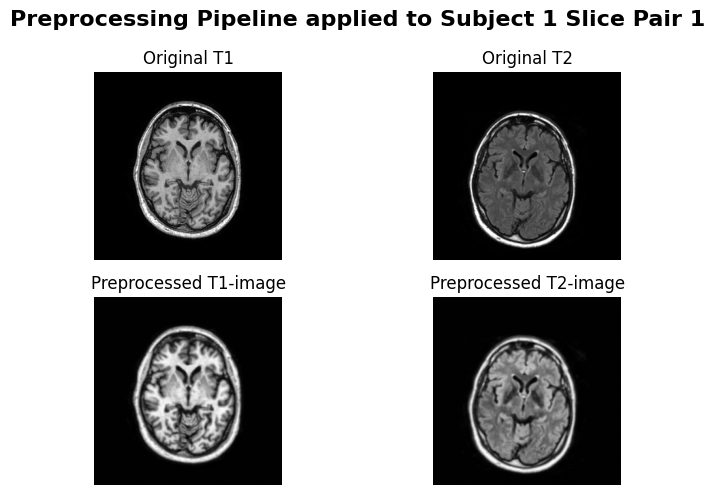

In [12]:
from scipy.ndimage import gaussian_filter
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Loading the images
Img1 = plt.imread(data_path + '1_1_t1.tif')
Img2 = plt.imread(data_path + '1_1_t2.tif')

# Gaussian smoothing
Img1_smooth = gaussian_filter(Img1, sigma=1)
Img2_smooth = gaussian_filter(Img2, sigma=1)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
Img1_clahe = clahe.apply(Img1_smooth.astype(np.uint8))
Img2_clahe = clahe.apply(Img2_smooth.astype(np.uint8))

# Normalization
Img1_norm = (Img1_clahe - Img1_clahe.mean()) / Img1_clahe.std()
Img2_norm = (Img2_clahe - Img2_clahe.mean()) / Img2_clahe.std()

fig, ax = plt.subplots(2, 2, figsize=(8,5))
fig.suptitle("Preprocessing Pipeline applied to Subject 1 Slice Pair 1", fontsize=16, fontweight='bold')
ax[0,0].imshow(Img1, cmap='gray')
ax[0,0].set_title('Original T1')
ax[0,0].axis('off')

ax[0,1].imshow(Img2, cmap='gray')
ax[0,1].set_title('Original T2')
ax[0,1].axis('off')

ax[1,0].imshow(Img1_norm, cmap='gray')
ax[1,0].set_title('Preprocessed T1-image')
ax[1,0].axis('off')

ax[1,1].imshow(Img2_norm, cmap='gray')
ax[1,1].set_title('Preprocessed T2-image')
ax[1,1].axis('off')

plt.tight_layout()
plt.show()

#### 3.2 Performing image registration for each image pair

We need to redefine the intensity-based registration function to use preprocessing:

In [6]:
from scipy.ndimage import gaussian_filter
import cv2
import numpy as np


def intensity_based_registration_demo_with_preprocessing(I_path, Im_path, similarity_func, mu, num_iter, init_val, title):
    # I_path: path to the fixed image
    # Im_path: path to the moving image
    # similarity_func: similarity function 
    # mu: learning rate
    # num_iter: number of iterations 
    # init_val: initial parameter values for the transformation (default = [0, 0, 0] for rigid registration)
    # title: title of the plot

    # Read the fixed and moving image:
    I = plt.imread(I_path)
    Im = plt.imread(Im_path)

    # Gaussian smoothing
    I, Im = gaussian_filter(I, sigma=1), gaussian_filter(Im, sigma=1)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    I, Im = clahe.apply(I.astype(np.uint8)), clahe.apply(Im.astype(np.uint8))

    # Normalization
    I, Im = (I - I.mean()) / I.std(), (Im - Im.mean()) / Im.std()


    # Initial parameter values:
    x = init_val
    # NOTE: for affine registration you have to initialize more parameters and 
    # the scaling parameters should be initialized to 1 instead of 0.
    # Similarity function:
    fun = lambda x: similarity_func(I, Im, x, return_transform=False)
    # Learning rate:
    mu = mu
    # Number of iterations
    num_iter = num_iter
    iterations = np.arange(1, num_iter+1)
    similarity = np.full((num_iter, 1), np.nan)
    fig = plt.figure(figsize=(14,6))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    # fixed and moving image, and parameters
    ax1 = fig.add_subplot(121)
    # fixed image
    im1 = ax1.imshow(I)
    # moving image
    im2 = ax1.imshow(I, alpha=0.7)
    # parameters
    txt = ax1.text(0.05, 0.95,
        np.array2string(x, precision=3, floatmode='fixed'),
        bbox={'facecolor': 'white', 'alpha': 1, 'pad': 10},
        transform=ax1.transAxes)
    # 'learning' curve
    ax2 = fig.add_subplot(122, xlim=(0, num_iter), ylim=(0, 1))
    learning_curve, = ax2.plot(iterations, similarity, lw=2)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Similarity')
    ax2.grid()
    # perform 'num_iter' gradient ascent updates
    for k in np.arange(num_iter):
        # gradient ascent
        g = ngradient(fun, x)
        x += g*mu
        # for visualization of the result
        S, Im_t, Th = similarity_func(I, Im, x, return_transform=True)
        clear_output(wait = True)
        # update moving image and parameters
        im2.set_data(Im_t)
        txt.set_text(np.array2string(x, precision=5, floatmode='fixed'))
        # update 'learning' curve
        similarity[k] = S
        learning_curve.set_ydata(similarity)
        display(fig)
    plt.close(fig)
    
    return S, Im_t, Th

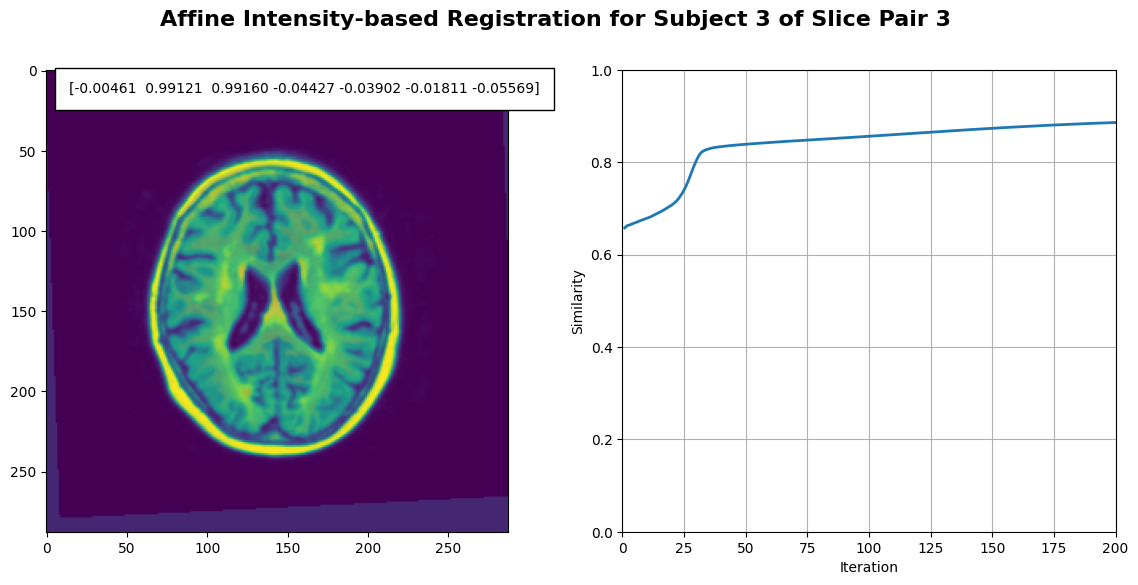

In [ ]:
data_path = '../data/image_data/'
image_pairs = [
               (data_path + '1_1_t1.tif', data_path + '1_1_t2.tif'),
               (data_path + '1_2_t1.tif', data_path + '1_2_t2.tif'),
               (data_path + '1_3_t1.tif', data_path + '1_3_t2.tif'),
               (data_path + '2_1_t1.tif', data_path + '2_1_t2.tif'),
               (data_path + '2_2_t1.tif', data_path + '2_2_t2.tif'),
               (data_path + '2_3_t1.tif', data_path + '2_3_t2.tif'),
               (data_path + '3_1_t1.tif', data_path + '3_1_t2.tif'),
               (data_path + '3_2_t1.tif', data_path + '3_2_t2.tif'),
               (data_path + '3_3_t1.tif', data_path + '3_3_t2.tif')]

prepro_S = []
prepro_Im_t = []
prepro_th = []
for i, (Im1_path, Im2_path) in enumerate(image_pairs):
    S, Im_t, Th = intensity_based_registration_demo_with_preprocessing(
        I_path = Im1_path,   # path to fixed image -> the T1-weighted image
        Im_path = Im2_path,  # path to moving image -> the T2-weighted image
        similarity_func = affine_corr,
        mu = 0.0005,
        num_iter = 200,
        init_val = np.array([0., 1., 1., 0., 0., 0., 0.]),  #[rot, scale x, scale y, shear x, shear y, trans x, trans y]
        title = f"Affine Intensity-based Registration for Subject {Im1_path[-10]} of Slice Pair {Im1_path[-8]}")
    prepro_S.append(S)
    prepro_Im_t.append(Im_t)
    prepro_th.append(Th)

#### 3.3 Evaluating the results of preprocessing

In [23]:
Prepro_registration_CC = []
Prepro_registration_MI = []
Prepro_registration_Dice = []
Prepro_registration_Jaccard = []

for i, (Im1_path, Im2_path) in enumerate(image_pairs):
    Im1 = plt.imread(Im1_path)
    Im2 = plt.imread(Im2_path)
    # Note: we need to transform the original, unprocessed image using the acquired
    #       transformation matrix obtained with the preprocessed images!
    Im_t, _ = image_transform(Im2, prepro_th[i])
    # Computing the registration errors
    CC = correlation(Im1, Im_t)
    MI = mutual_information(joint_histogram(Im1, Im_t))
    Dice = dice_score(Im1 > 0, Im_t > 0)
    Jaccard = jaccard_index(Im1 > 0, Im_t > 0)
    Prepro_registration_CC.append(CC)
    Prepro_registration_MI.append(MI)
    Prepro_registration_CC.append(Dice)
    Prepro_registration_MI.append(Jaccard)
    print(f"Subject {Im1_path[-10]} slice pair {Im1_path[-8]}: ")
    print(f"       CC: {CC:.4f}")
    print(f"       MI: {MI:.4f}")
    print(f"     Dice: {Dice:.4f}")
    print(f"  Jaccard: {Jaccard:.4f}")  

Subject 1 slice pair 1: 
       CC: 0.8529
       MI: 0.6876
     Dice: 0.9000
  Jaccard: 0.8182
Subject 1 slice pair 2: 
       CC: 0.8706
       MI: 0.6953
     Dice: 0.9016
  Jaccard: 0.8209
Subject 1 slice pair 3: 
       CC: 0.8683
       MI: 0.6629
     Dice: 0.8750
  Jaccard: 0.7777
Subject 2 slice pair 1: 
       CC: 0.8864
       MI: 0.6876
     Dice: 0.8768
  Jaccard: 0.7807
Subject 2 slice pair 2: 
       CC: 0.9020
       MI: 0.6828
     Dice: 0.8865
  Jaccard: 0.7962
Subject 2 slice pair 3: 
       CC: 0.6094
       MI: 0.4041
     Dice: 0.8399
  Jaccard: 0.7240
Subject 3 slice pair 1: 
       CC: 0.8920
       MI: 0.7294
     Dice: 0.8990
  Jaccard: 0.8166
Subject 3 slice pair 2: 
       CC: 0.5517
       MI: 0.4210
     Dice: 0.8528
  Jaccard: 0.7433
Subject 3 slice pair 3: 
       CC: 0.8749
       MI: 0.6557
     Dice: 0.8742
  Jaccard: 0.7764


#### 3.4 Repeating poor registration with different hyperparameters

We again see that image pair 3 of subject 2, and image pair 2 of subject 3 perform not too great. We use the same change in initial values and learning rate and repeat the registration procedure:

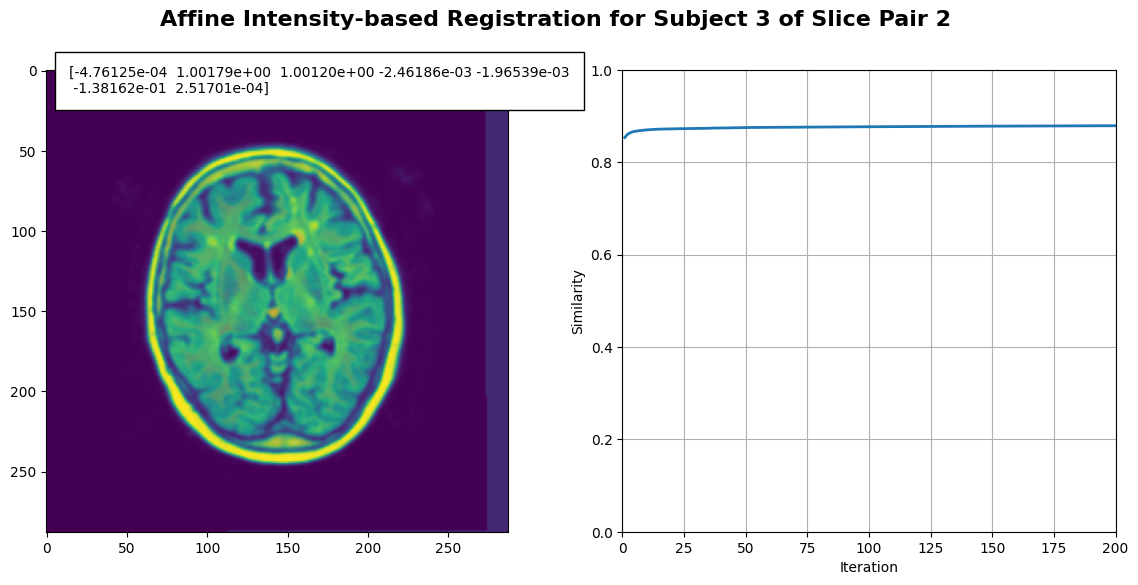

Subject 3 slice pair 2: 
       CC: 0.8807
       MI: 0.0000
     Dice: 0.8875
  Jaccard: 0.7978


In [13]:
data_path = '../data/image_data/'
image_pairs = [
            #    (data_path + '2_3_t1.tif', data_path + '2_3_t2.tif')]
               (data_path + '3_2_t1.tif', data_path + '3_2_t2.tif')]

for i, (Im1_path, Im2_path) in enumerate(image_pairs):
    S, Im_t, Th = intensity_based_registration_demo_with_preprocessing(
        I_path = Im1_path,   # path to fixed image -> the T1-weighted image
        Im_path = Im2_path,  # path to moving image -> the T2-weighted image
        similarity_func = affine_corr,
        mu = 0.0001,
        num_iter = 200,
        init_val = np.array([0., 1., 1., 0., 0., -0.15, 0.]),  #[rot, scale x, scale y, shear x, shear y, trans x, trans y]
        title = f"Affine Intensity-based Registration for Subject {Im1_path[-10]} of Slice Pair {Im1_path[-8]}")

    Im1 = plt.imread(Im1_path)
    # Computing the registration errors
    CC = correlation(Im1, Im_t)
    MI = mutual_information(joint_histogram(Im1, Im_t))
    Dice = dice_score(Im1 > 0, Im_t > 0)
    Jaccard = jaccard_index(Im1 > 0, Im_t > 0)
    print(f"Subject {Im1_path[-10]} slice pair {Im1_path[-8]}: ")
    print(f"       CC: {CC:.4f}")
    print(f"       MI: {MI:.4f}")
    print(f"     Dice: {Dice:.4f}")
    print(f"  Jaccard: {Jaccard:.4f}")

### 4. Edge-based intensity-based registration

The last method that shall be investigated is edge-based registration. In this method, we will first apply an edge detection filter to the images, and then perform intensity-based registration on the resulting edge images. The specific edge detection filter that we will use is the Canny edge detector, which is a popular edge detection algorithm that uses a multi-stage process to detect edges in images. 

#### 4.1 Showcasing the Canny edge-detector

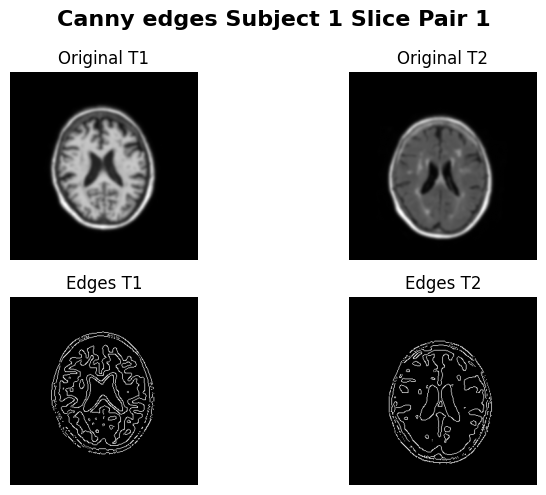

In [83]:
import cv2
import matplotlib.pyplot as plt

# Loading slice pair 1 of subject 1
Img1 = plt.imread(data_path + '3_3_t1.tif')
Img2 = plt.imread(data_path + '3_3_t2.tif')

# Normalization
Img1 = (Img1 - Img1.mean()) / Img1.std()
Img2 = (Img2 - Img2.mean()) / Img2.std()

# Gaussian smoothing
Img1, Img2 = gaussian_filter(Img1, sigma=2), gaussian_filter(Img2, sigma=2)

# Canny edge detection
edges1 = cv2.Canny(Img1.astype('uint8'),threshold1=1.5,threshold2=2)
edges2 = cv2.Canny(Img2.astype('uint8'),threshold1=1.5,threshold2=2)


# Plot
fig, ax = plt.subplots(2, 2, figsize=(8,5))
fig.suptitle("Canny edges Subject 1 Slice Pair 1", fontsize=16, fontweight='bold')
ax[0,0].imshow(Img1, cmap='gray')
ax[0,0].set_title('Original T1')
ax[0,0].axis('off')

ax[0,1].imshow(Img2, cmap='gray')
ax[0,1].set_title('Original T2')
ax[0,1].axis('off')

ax[1,0].imshow(edges1, cmap='gray')
ax[1,0].set_title('Edges T1')
ax[1,0].axis('off')

ax[1,1].imshow(edges2, cmap='gray')
ax[1,1].set_title('Edges T2')
ax[1,1].axis('off')

plt.tight_layout()
plt.show()

#### 4.2 Performing image registration for each image pair

In [80]:
from scipy.ndimage import gaussian_filter
import cv2
import numpy as np


def intensity_based_registration_demo_with_Canny(I_path, Im_path, similarity_func, mu, num_iter, init_val, title):
    # I_path: path to the fixed image
    # Im_path: path to the moving image
    # similarity_func: similarity function 
    # mu: learning rate
    # num_iter: number of iterations 
    # init_val: initial parameter values for the transformation (default = [0, 0, 0] for rigid registration)
    # title: title of the plot

    # Read the fixed and moving image:
    I = plt.imread(I_path)
    Im = plt.imread(Im_path)

   # Normalization
    I = (I - I.mean()) / I.std()
    Im = (Im - Im.mean()) / Im.std()

    # Gaussian smoothing
    I, Im = gaussian_filter(I, sigma=2), gaussian_filter(Im, sigma=2)

    # Canny edge detection
    I = cv2.Canny(I.astype('uint8'),threshold1=1.5,threshold2=2)
    Im = cv2.Canny(Im.astype('uint8'),threshold1=1.5,threshold2=2)


    # Initial parameter values:
    x = init_val
    # NOTE: for affine registration you have to initialize more parameters and 
    # the scaling parameters should be initialized to 1 instead of 0.
    # Similarity function:
    fun = lambda x: similarity_func(I, Im, x, return_transform=False)
    # Learning rate:
    mu = mu
    # Number of iterations
    num_iter = num_iter
    iterations = np.arange(1, num_iter+1)
    similarity = np.full((num_iter, 1), np.nan)
    fig = plt.figure(figsize=(14,6))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    # fixed and moving image, and parameters
    ax1 = fig.add_subplot(121)
    # fixed image
    im1 = ax1.imshow(I)
    # moving image
    im2 = ax1.imshow(I, alpha=0.7)
    # parameters
    txt = ax1.text(0.05, 0.95,
        np.array2string(x, precision=3, floatmode='fixed'),
        bbox={'facecolor': 'white', 'alpha': 1, 'pad': 10},
        transform=ax1.transAxes)
    # 'learning' curve
    ax2 = fig.add_subplot(122, xlim=(0, num_iter), ylim=(0, 1))
    learning_curve, = ax2.plot(iterations, similarity, lw=2)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Similarity')
    ax2.grid()
    # perform 'num_iter' gradient ascent updates
    for k in np.arange(num_iter):
        # gradient ascent
        g = ngradient(fun, x)
        if k < 50:
            x += g*mu*10
        elif k < 125:
            x += g*mu*5
        else:
            x += g*mu
        # for visualization of the result
        S, Im_t, Th = similarity_func(I, Im, x, return_transform=True)
        clear_output(wait = True)
        # update moving image and parameters
        im2.set_data(Im_t)
        txt.set_text(np.array2string(x, precision=5, floatmode='fixed'))
        # update 'learning' curve
        similarity[k] = S
        learning_curve.set_ydata(similarity)
        display(fig)
    plt.close(fig)
    
    return S, Im_t, Th

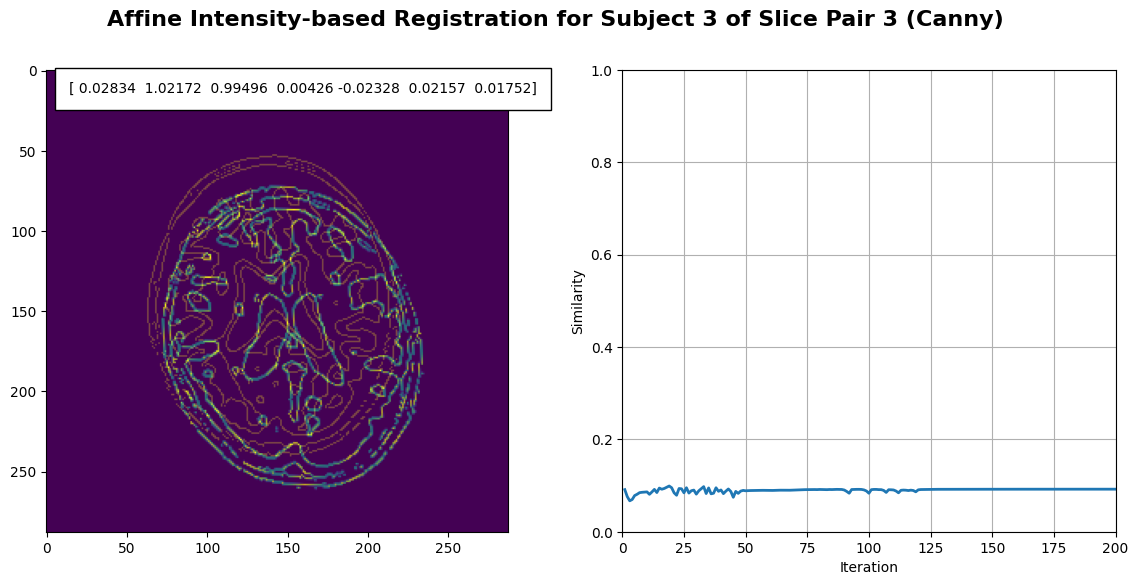

In [81]:
data_path = '../data/image_data/'
image_pairs = [
               (data_path + '1_1_t1.tif', data_path + '1_1_t2.tif'),
               (data_path + '1_2_t1.tif', data_path + '1_2_t2.tif'),
               (data_path + '1_3_t1.tif', data_path + '1_3_t2.tif'),
               (data_path + '2_1_t1.tif', data_path + '2_1_t2.tif'),
               (data_path + '2_2_t1.tif', data_path + '2_2_t2.tif'),
               (data_path + '2_3_t1.tif', data_path + '2_3_t2.tif'),
               (data_path + '3_1_t1.tif', data_path + '3_1_t2.tif'),
               (data_path + '3_2_t1.tif', data_path + '3_2_t2.tif'),
               (data_path + '3_3_t1.tif', data_path + '3_3_t2.tif')]

Canny_S = []
Canny_Im_t = []
Canny_th = []
for i, (Im1_path, Im2_path) in enumerate(image_pairs):
    S, Im_t, Th = intensity_based_registration_demo_with_Canny(
        I_path = Im1_path,   # path to fixed image -> the T1-weighted image
        Im_path = Im2_path,  # path to moving image -> the T2-weighted image
        similarity_func = affine_corr,
        mu = 0.0002,
        num_iter = 200,
        init_val = np.array([0., 1., 1., 0., 0., 0., 0.]),  #[rot, scale x, scale y, shear x, shear y, trans x, trans y]
        title = f"Affine Intensity-based Registration for Subject {Im1_path[-10]} of Slice Pair {Im1_path[-8]} (Canny)")
    Canny_S.append(S)
    Canny_Im_t.append(Im_t)
    Canny_th.append(Th)

#### 4.3 Evaluating the results of the Canny edge-detector

In [82]:
Canny_registration_CC = []
Canny_registration_MI = []
Canny_registration_Dice = []
Canny_registration_Jaccard = []

for i, (Im1_path, Im2_path) in enumerate(image_pairs):
    Im1 = plt.imread(Im1_path)
    Im2 = plt.imread(Im2_path)
    # Note: we need to transform the original, unprocessed image using the acquired
    #       transformation matrix obtained with the preprocessed & Canny-edge images!
    Im_t, _ = image_transform(Im2, Canny_th[i])
    # Computing the registration errors
    CC = correlation(Im1, Im_t)
    MI = mutual_information(joint_histogram(Im1, Im_t))
    Dice = dice_score(Im1 > 0, Im_t > 0)
    Jaccard = jaccard_index(Im1 > 0, Im_t > 0)
    Canny_registration_CC.append(CC)
    Canny_registration_MI.append(MI)
    Canny_registration_CC.append(Dice)
    Canny_registration_MI.append(Jaccard)
    print(f"Subject {Im1_path[-10]} slice pair {Im1_path[-8]}: ")
    print(f"       CC: {CC:.4f}")
    print(f"       MI: {MI:.4f}")
    print(f"     Dice: {Dice:.4f}")
    print(f"  Jaccard: {Jaccard:.4f}")    

Subject 1 slice pair 1: 
       CC: 0.5360
       MI: 0.4152
     Dice: 0.8714
  Jaccard: 0.7721
Subject 1 slice pair 2: 
       CC: 0.8444
       MI: 0.6584
     Dice: 0.9049
  Jaccard: 0.8263
Subject 1 slice pair 3: 
       CC: 0.7054
       MI: 0.5217
     Dice: 0.8709
  Jaccard: 0.7713
Subject 2 slice pair 1: 
       CC: 0.8729
       MI: 0.6605
     Dice: 0.8784
  Jaccard: 0.7832
Subject 2 slice pair 2: 
       CC: 0.6507
       MI: 0.4360
     Dice: 0.8773
  Jaccard: 0.7814
Subject 2 slice pair 3: 
       CC: 0.5682
       MI: 0.2999
     Dice: 0.7978
  Jaccard: 0.6637
Subject 3 slice pair 1: 
       CC: 0.6161
       MI: 0.4822
     Dice: 0.8904
  Jaccard: 0.8025
Subject 3 slice pair 2: 
       CC: 0.8506
       MI: 0.6910
     Dice: 0.8895
  Jaccard: 0.8010
Subject 3 slice pair 3: 
       CC: 0.5290
       MI: 0.3270
     Dice: 0.8069
  Jaccard: 0.6763
